# Outlier Detection — Cardio (ODDS) & Heart Failure Datasets

**Datasets:**
- [Cardio — ODDS benchmark](https://github.com/BELLoney/Outlier-detection) — labeled, 1831 × 21 features, ~9.6% outliers  
- [Heart Failure Prediction](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/data) — unlabeled outlier analysis, 918 × 5 numerical features

**Methods covered (Phase 1):**
1. **Univariate** — Medie ± k·SD and 1.5×IQR (Tukey fences)
2. **Mahalanobis distance** — multivariate, chi-squared threshold
3. **Local Outlier Factor (LOF)** — density-based, multivariate

**Standardization policy:**
- Medie ± k·SD, IQR, Mahalanobis: **no standardization needed** (scale-invariant or per-feature)  
- LOF on Heart Failure: **StandardScaler applied** (Cardio already min-max normalized)

In [1]:
%pip install -q pandas numpy scipy matplotlib seaborn scikit-learn

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import io
import urllib.request

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy import io as sio
from scipy.stats import chi2
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

Matplotlib is building the font cache; this may take a moment.


## 0. Data Loading

### 0a. Cardio Dataset (ODDS — labeled)

Loaded from the [BELLoney/Outlier-detection](https://github.com/BELLoney/Outlier-detection) repository.  
The `.mat` file stores a single merged matrix `trandata` of shape `(n, d+1)` where the last column is the label (`1` = outlier, `0` = inlier).  
Features are already **min-max normalized** to `[0, 1]`.

In [3]:
CARDIO_URL = (
    "https://raw.githubusercontent.com/BELLoney/Outlier-detection/"
    "master/ODDS/trandata/cardio.mat"
)

raw = urllib.request.urlopen(CARDIO_URL).read()
mat = sio.loadmat(io.BytesIO(raw))

# trandata shape: (n, d+1) — last column is label (1=outlier, 0=inlier)
data = mat["trandata"].astype(float)
X_cardio = data[:, :-1]
y_cardio  = data[:, -1].astype(int)

n_feat = X_cardio.shape[1]
feat_names = [f"feature_{i+1}" for i in range(n_feat)]
df_cardio = pd.DataFrame(X_cardio, columns=feat_names)
df_cardio["label"] = y_cardio

print(f"Shape: {df_cardio.shape}")
print(f"Outliers (label=1): {y_cardio.sum()} / {len(y_cardio)} ({y_cardio.mean()*100:.1f}%)")
df_cardio.describe().round(3)

Shape: (1831, 22)
Outliers (label=1): 176 / 1831 (9.6%)


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,label
count,1831.000,1831.000,1831.000,1831.000,1831.000,1831.000,1831.000,1831.000,1831.000,1831.000,1831.000,1831.000,1831.000,1831.000,1831.000,1831.000,1831.000,1831.000,1831.000,1831.000,1831.000,1831.000
mean,0.481,0.189,0.020,0.313,0.137,0.003,0.031,0.435,0.183,0.074,0.162,0.400,0.371,0.364,0.233,0.034,0.598,0.550,0.547,0.077,0.651,0.096
std,0.175,0.205,0.099,0.192,0.200,0.050,0.113,0.223,0.127,0.177,0.116,0.213,0.257,0.157,0.161,0.069,0.131,0.144,0.133,0.111,0.306,0.295
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.352,0.000,0.000,0.171,0.000,0.000,0.000,0.240,0.088,0.000,0.083,0.215,0.138,0.259,0.111,0.000,0.528,0.468,0.459,0.011,0.500,0.000
50%,0.481,0.130,0.000,0.319,0.000,0.000,0.000,0.427,0.162,0.000,0.148,0.395,0.358,0.353,0.222,0.000,0.598,0.560,0.550,0.033,0.500,0.000
75%,0.593,0.324,0.004,0.451,0.242,0.000,0.000,0.613,0.235,0.044,0.219,0.559,0.596,0.457,0.333,0.000,0.685,0.651,0.642,0.097,1.000,0.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


### 0b. Heart Failure Dataset (from Task 1)

Only the 5 **numerical** columns are used for outlier detection — categorical variables and the target are excluded.

In [4]:
HF_URL = (
    "https://raw.githubusercontent.com/benbobyabraham/"
    "heart_failure_prediction_dataset_kaggle/main/heart.csv"
)

df_hf_full = pd.read_csv(HF_URL)
num_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
X_hf = df_hf_full[num_cols].copy()

print(f"Full dataset shape: {df_hf_full.shape}")
print(f"Numerical features used: {num_cols}")
X_hf.describe().round(2)

Full dataset shape: (918, 12)
Numerical features used: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,198.80,136.81,0.89
std,9.43,18.51,109.38,25.46,1.07
min,28.00,0.00,0.00,60.00,-2.60
25%,47.00,120.00,173.25,120.00,0.00
50%,54.00,130.00,223.00,138.00,0.60
75%,60.00,140.00,267.00,156.00,1.50
max,77.00,200.00,603.00,202.00,6.20


## 1. Univariate Outlier Detection

Both rules operate **per feature** in the original scale — no standardization is required.

A point is flagged as a **row-level outlier** if it exceeds the threshold on **any** of the features (union across features).

### 1a. Medie ± k·SD Rule (k = 3)

A value $x$ is an outlier on feature $j$ if $|x - \mu_j| > k \cdot \sigma_j$,  
i.e., $x \notin [\mu_j - k\sigma_j,\; \mu_j + k\sigma_j]$.

In [5]:
def mean_sd_outlier_mask(X, k=3.0):
    X = np.asarray(X, dtype=float)
    mu  = X.mean(axis=0)
    std = np.where(X.std(axis=0) == 0, 1e-12, X.std(axis=0))
    per_feature = np.abs(X - mu) > k * std
    return per_feature, per_feature.any(axis=1)


K = 3.0

pf_sd_cardio, sd_mask_cardio = mean_sd_outlier_mask(X_cardio, k=K)
pf_sd_hf,     sd_mask_hf     = mean_sd_outlier_mask(X_hf.values, k=K)

print(f"[Cardio]        Medie±{K}·SD: {sd_mask_cardio.sum()} flagged ({sd_mask_cardio.mean()*100:.1f}%)")
print(f"[Heart Failure] Medie±{K}·SD: {sd_mask_hf.sum()} flagged ({sd_mask_hf.mean()*100:.1f}%)")

[Cardio]        Medie±3.0·SD: 299 flagged (16.3%)
[Heart Failure] Medie±3.0·SD: 19 flagged (2.1%)


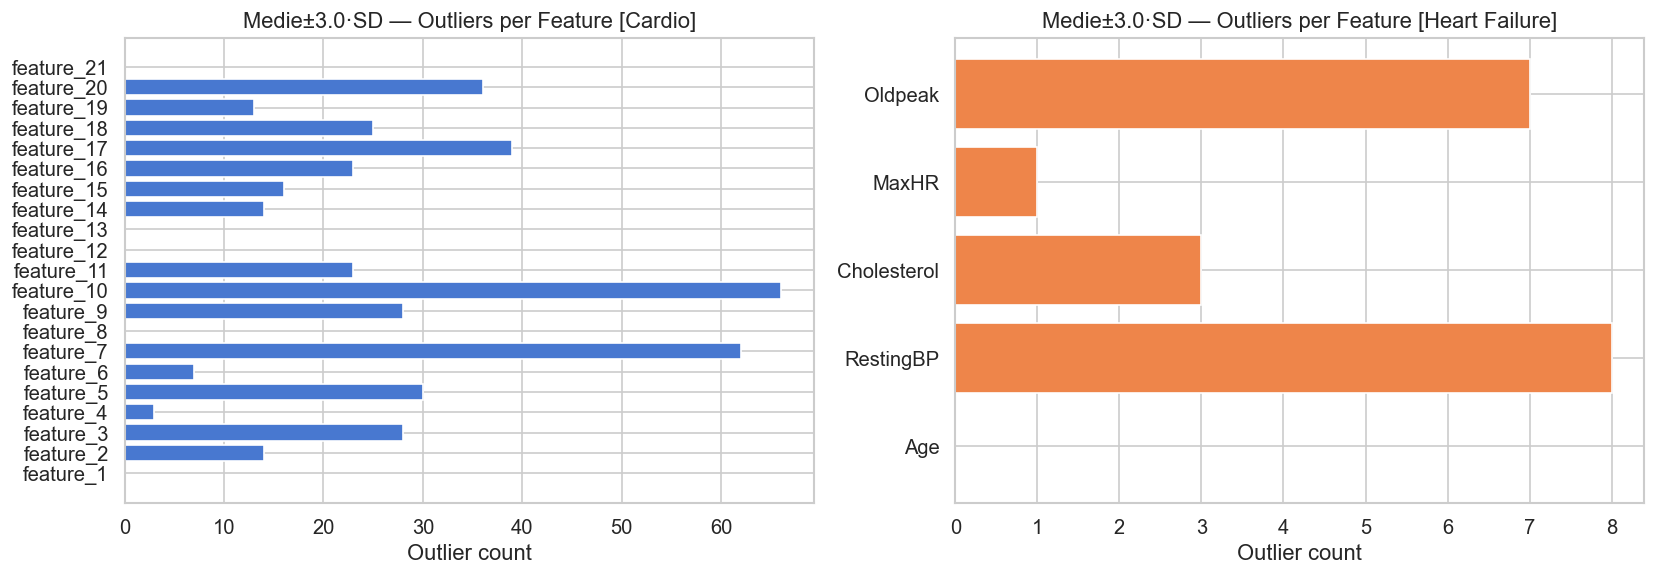

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(feat_names, pf_sd_cardio.sum(axis=0), color=sns.color_palette()[0])
axes[0].set_xlabel("Outlier count")
axes[0].set_title(f"Medie±{K}·SD — Outliers per Feature [Cardio]")

axes[1].barh(num_cols, pf_sd_hf.sum(axis=0), color=sns.color_palette()[1])
axes[1].set_xlabel("Outlier count")
axes[1].set_title(f"Medie±{K}·SD — Outliers per Feature [Heart Failure]")

plt.tight_layout()
plt.show()

### 1b. IQR Rule (1.5×IQR — Tukey Fences)

A value $x$ is an outlier on feature $j$ if:
$$x < Q1_j - 1.5 \cdot IQR_j \quad\text{or}\quad x > Q3_j + 1.5 \cdot IQR_j$$

**Note on degenerate features:** when $Q1 = Q3$ (IQR = 0) the fence collapses to a single point
and every non-zero value would be flagged — a meaningless result. This occurs on near-constant
or highly sparse features (e.g., Cardio features 6, 7, 16 which are ≥75% zero).
These features are **excluded** from the IQR computation. Even after this fix, IQR
still flags a large fraction of Cardio because several remaining features have heavily
right-skewed distributions — a known limitation of Tukey fences on non-Gaussian data.

In [7]:
def iqr_outlier_mask(X, multiplier=1.5):
    X = np.asarray(X, dtype=float)
    Q1  = np.percentile(X, 25, axis=0)
    Q3  = np.percentile(X, 75, axis=0)
    IQR = Q3 - Q1
    lower = Q1 - multiplier * IQR
    upper = Q3 + multiplier * IQR
    # Skip features where IQR=0: fence collapses to a single point
    # and every non-zero value would be flagged (meaningless for binary features)
    valid = IQR > 0
    per_feature = np.zeros(X.shape, dtype=bool)
    per_feature[:, valid] = (X[:, valid] < lower[valid]) | (X[:, valid] > upper[valid])
    return per_feature, per_feature.any(axis=1), lower, upper


pf_iqr_cardio, iqr_mask_cardio, lo_c, hi_c = iqr_outlier_mask(X_cardio)
pf_iqr_hf,     iqr_mask_hf,     lo_h, hi_h = iqr_outlier_mask(X_hf.values)

Q1_c = np.percentile(X_cardio, 25, axis=0)
Q3_c = np.percentile(X_cardio, 75, axis=0)
n_skip = int((Q3_c - Q1_c == 0).sum())

print(f"[Cardio]        IQR 1.5× ({n_skip} features skipped — IQR=0): "
      f"{iqr_mask_cardio.sum()} flagged ({iqr_mask_cardio.mean()*100:.1f}%)")
print(f"[Heart Failure] IQR 1.5×: {iqr_mask_hf.sum()} flagged ({iqr_mask_hf.mean()*100:.1f}%)")

[Cardio]        IQR 1.5×: 1102 flagged (60.2%)
[Heart Failure] IQR 1.5×: 216 flagged (23.5%)


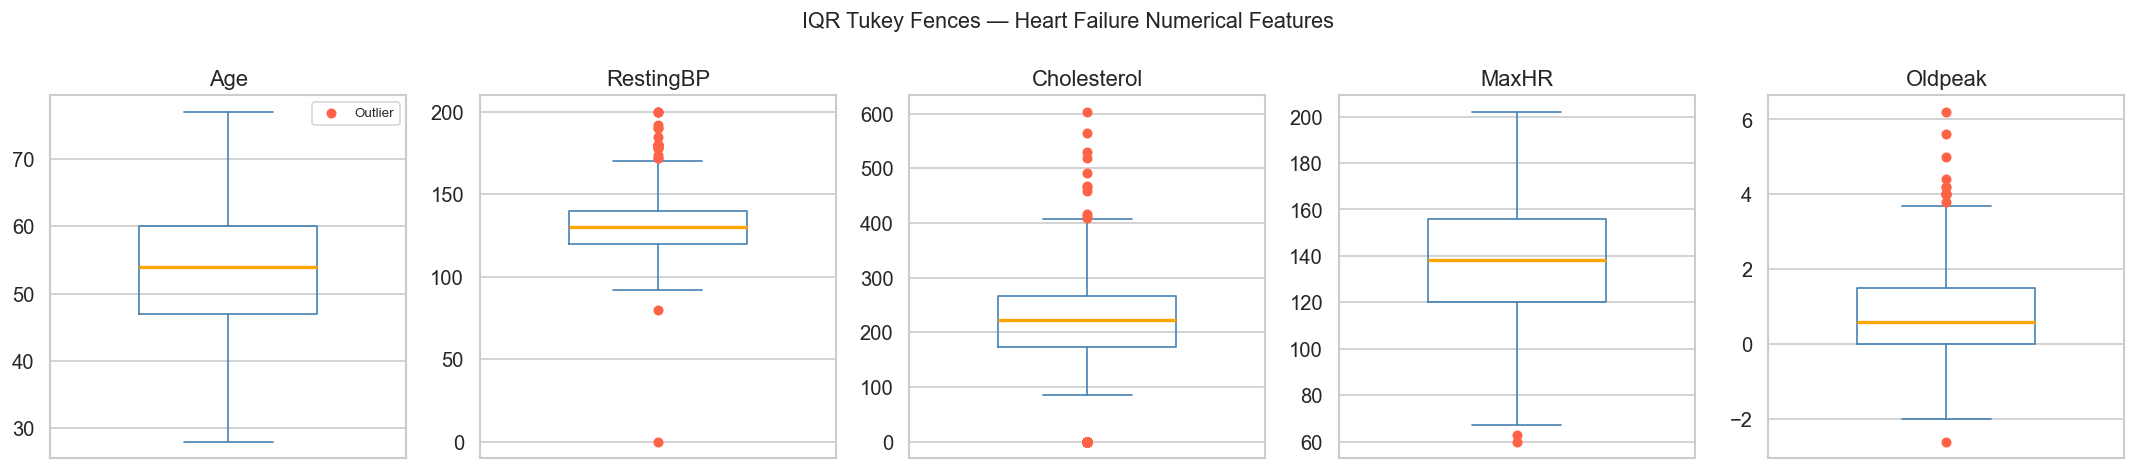

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(num_cols):
    vals = X_hf[col].values
    feature_mask = pf_iqr_hf[:, i]

    axes[i].boxplot(vals, whis=1.5, widths=0.5,
                    boxprops=dict(color="steelblue"),
                    whiskerprops=dict(color="steelblue"),
                    capprops=dict(color="steelblue"),
                    medianprops=dict(color="orange", linewidth=2),
                    flierprops=dict(marker="", alpha=0))
    axes[i].scatter([1] * feature_mask.sum(), vals[feature_mask],
                    color="tomato", zorder=5, s=25, label="Outlier")
    axes[i].set_title(col)
    axes[i].set_xticks([])
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle("IQR Tukey Fences — Heart Failure Numerical Features", fontsize=13)
plt.tight_layout()
plt.show()

### 1c. Univariate Summary

In [9]:
univariate_mask_cardio = sd_mask_cardio | iqr_mask_cardio
univariate_mask_hf     = sd_mask_hf     | iqr_mask_hf

pd.DataFrame({
    "Method": ["Medie±3·SD", "IQR 1.5×", "Univariate Union"],
    "Cardio flagged":       [sd_mask_cardio.sum(), iqr_mask_cardio.sum(), univariate_mask_cardio.sum()],
    "Cardio %":             [sd_mask_cardio.mean()*100, iqr_mask_cardio.mean()*100, univariate_mask_cardio.mean()*100],
    "HeartFailure flagged": [sd_mask_hf.sum(), iqr_mask_hf.sum(), univariate_mask_hf.sum()],
    "HeartFailure %":       [sd_mask_hf.mean()*100, iqr_mask_hf.mean()*100, univariate_mask_hf.mean()*100],
}).round(1)

,Method,Cardio flagged,Cardio %,HeartFailure flagged,HeartFailure %
0,Medie±3·SD,299,16.3,19,2.1
1,IQR 1.5×,1102,60.2,216,23.5
2,Univariate Union,1102,60.2,216,23.5


## 2. Mahalanobis Distance

The Mahalanobis distance of a point $\mathbf{x}$ from the distribution centroid $\boldsymbol{\mu}$ is:
$$D_M(\mathbf{x}) = \sqrt{(\mathbf{x} - \boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})}$$

Under multivariate normality, $D_M^2 \sim \chi^2(d)$.  
**Threshold:** $D_M > \sqrt{\chi^2(d,\, 0.975)}$ (97.5th percentile).

Mahalanobis distance is **scale-invariant** by construction — no standardization is needed.

In [10]:
def mahalanobis_distances(X):
    X = np.asarray(X, dtype=float)
    mu      = X.mean(axis=0)
    cov_inv = np.linalg.pinv(np.cov(X, rowvar=False))  # pinv handles near-singular covariance
    diff    = X - mu
    d2 = np.einsum("ij,jk,ik->i", diff, cov_inv, diff)
    return np.sqrt(np.maximum(d2, 0.0))

### 2a. Mahalanobis on Cardio Dataset

In [11]:
d_c, alpha = X_cardio.shape[1], 0.975
thresh_mahal_c = np.sqrt(chi2.ppf(alpha, df=d_c))

dist_cardio     = mahalanobis_distances(X_cardio)
mahal_mask_cardio = dist_cardio > thresh_mahal_c

print(f"d = {d_c},  χ²({d_c}, 0.975) = {chi2.ppf(alpha, d_c):.2f}")
print(f"Threshold D_M = {thresh_mahal_c:.3f}")
print(f"Cardio flagged: {mahal_mask_cardio.sum()} "
      f"({mahal_mask_cardio.mean()*100:.1f}%)")

d = 21,  χ²(21, 0.975) = 35.48
Threshold D_M = 5.956
Cardio flagged: 185 (10.1%)


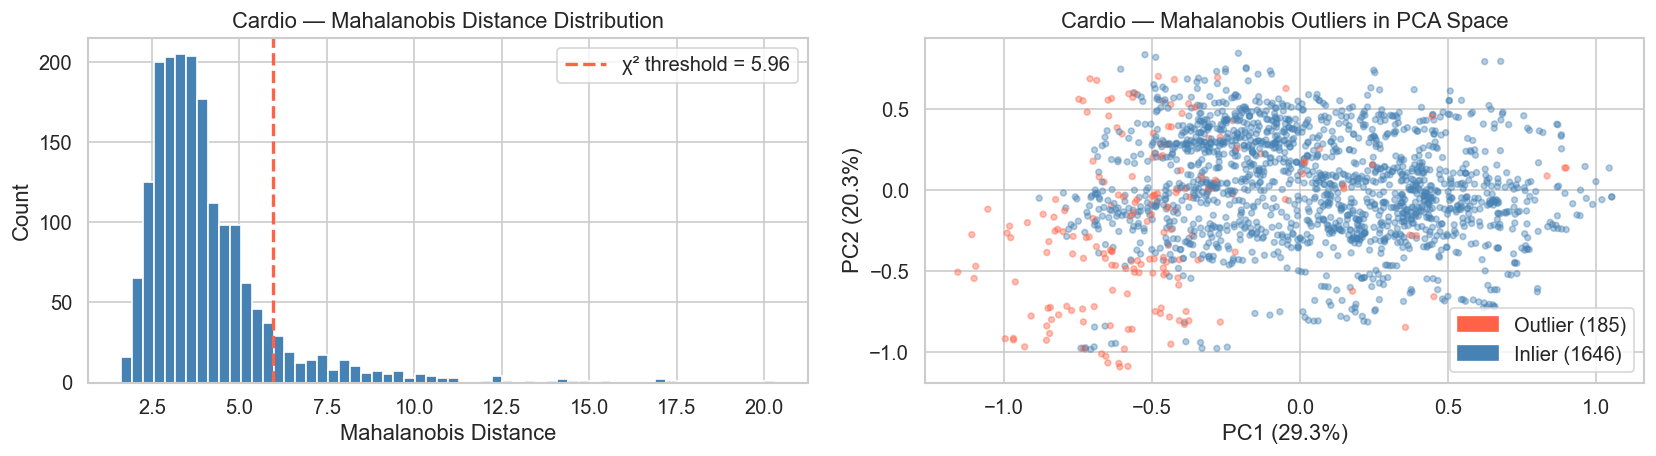

In [12]:
pca2_c = PCA(n_components=2)
X_pca_c = pca2_c.fit_transform(X_cardio)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(dist_cardio, bins=60, color="steelblue", edgecolor="white")
axes[0].axvline(thresh_mahal_c, color="tomato", ls="--", lw=2,
                label=f"χ² threshold = {thresh_mahal_c:.2f}")
axes[0].set_xlabel("Mahalanobis Distance")
axes[0].set_ylabel("Count")
axes[0].set_title("Cardio — Mahalanobis Distance Distribution")
axes[0].legend()

colors = np.where(mahal_mask_cardio, "tomato", "steelblue")
axes[1].scatter(X_pca_c[:, 0], X_pca_c[:, 1], c=colors, alpha=0.4, s=12)
axes[1].set_xlabel(f"PC1 ({pca2_c.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca2_c.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("Cardio — Mahalanobis Outliers in PCA Space")
axes[1].legend(handles=[
    mpatches.Patch(color="tomato",    label=f"Outlier ({mahal_mask_cardio.sum()})"),
    mpatches.Patch(color="steelblue", label=f"Inlier ({(~mahal_mask_cardio).sum()})"),
])

plt.tight_layout()
plt.show()

### 2b. Mahalanobis on Heart Failure Dataset

d = 5,  χ²(5, 0.975) = 12.83
Threshold D_M = 3.582
Heart Failure flagged: 33 (3.6%)


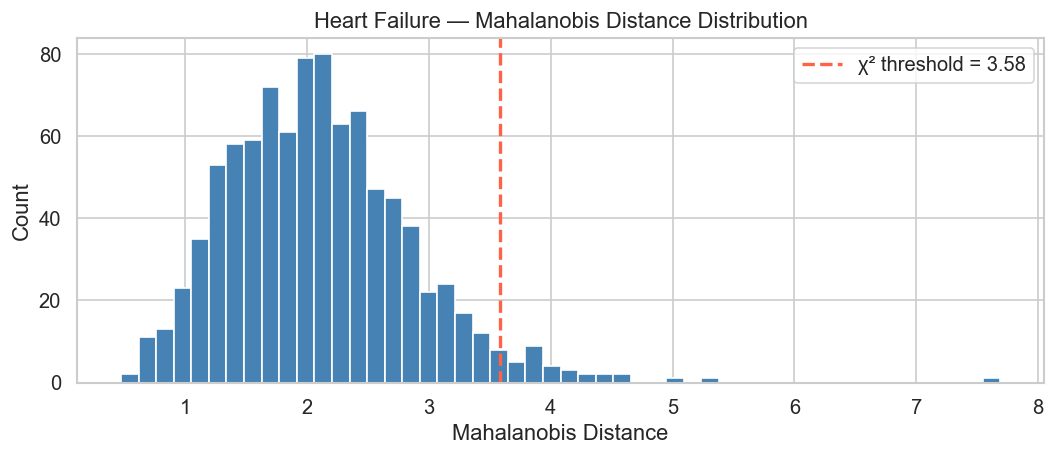

In [13]:
d_h = X_hf.shape[1]
thresh_mahal_h = np.sqrt(chi2.ppf(alpha, df=d_h))

dist_hf         = mahalanobis_distances(X_hf.values)
mahal_mask_hf   = dist_hf > thresh_mahal_h

print(f"d = {d_h},  χ²({d_h}, 0.975) = {chi2.ppf(alpha, d_h):.2f}")
print(f"Threshold D_M = {thresh_mahal_h:.3f}")
print(f"Heart Failure flagged: {mahal_mask_hf.sum()} "
      f"({mahal_mask_hf.mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(dist_hf, bins=50, color="steelblue", edgecolor="white")
ax.axvline(thresh_mahal_h, color="tomato", ls="--", lw=2,
           label=f"χ² threshold = {thresh_mahal_h:.2f}")
ax.set_xlabel("Mahalanobis Distance")
ax.set_ylabel("Count")
ax.set_title("Heart Failure — Mahalanobis Distance Distribution")
ax.legend()
plt.tight_layout()
plt.show()

### 2c. Multiple Thresholds — Mahalanobis (Cardio)

The document requires testing **multiple score thresholds** for each multivariate method.  
For Mahalanobis, the natural parameter is the chi-squared quantile **α** used to set the distance threshold.  
We sweep α and also plot the full Precision–Recall curve by thresholding the raw distance scores.

In [ ]:
alpha_values = [0.70, 0.80, 0.85, 0.90, 0.925, 0.95, 0.975, 0.99, 0.999]

rows = []
for a in alpha_values:
    t    = np.sqrt(chi2.ppf(a, df=d_c))
    pred = (dist_cardio > t).astype(int)
    rows.append({
        "chi2 alpha": a,
        "Threshold D_M": round(t, 3),
        "Flagged": pred.sum(),
        "Flagged %": round(pred.mean()*100, 1),
        "Precision": round(precision_score(y_cardio, pred, zero_division=0), 3),
        "Recall":    round(recall_score(y_cardio, pred, zero_division=0), 3),
        "F1":        round(f1_score(y_cardio, pred, zero_division=0), 3),
    })

mahal_thresh_df = pd.DataFrame(rows)
mahal_thresh_df

In [ ]:
thresholds_sweep_m = np.percentile(dist_cardio, np.linspace(0, 100, 1000))
prec_curve_m, rec_curve_m, f1_curve_m = [], [], []
for t in thresholds_sweep_m:
    pred = (dist_cardio > t).astype(int)
    prec_curve_m.append(precision_score(y_cardio, pred, zero_division=0))
    rec_curve_m.append(recall_score(y_cardio, pred, zero_division=0))
    f1_curve_m.append(f1_score(y_cardio, pred, zero_division=0))

p_curr_m = precision_score(y_cardio, mahal_mask_cardio.astype(int))
r_curr_m = recall_score(y_cardio, mahal_mask_cardio.astype(int))
best_f1_idx_m = int(np.argmax(f1_curve_m))
best_thresh_m = thresholds_sweep_m[best_f1_idx_m]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rec_curve_m, prec_curve_m, color="steelblue", lw=1.5)
axes[0].scatter([r_curr_m], [p_curr_m], color="tomato", s=100, zorder=5,
                label=f"χ²(0.975) → P={p_curr_m:.3f}, R={r_curr_m:.3f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Mahalanobis — Precision–Recall Curve (Cardio)")
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

axes[1].plot(thresholds_sweep_m, prec_curve_m, label="Precision", color="#1f77b4")
axes[1].plot(thresholds_sweep_m, rec_curve_m,  label="Recall",    color="#ff7f0e")
axes[1].plot(thresholds_sweep_m, f1_curve_m,   label="F1",        color="#2ca02c")
axes[1].axvline(thresh_mahal_c, color="tomato",  ls="--", lw=1.5,
                label=f"χ²(0.975) = {thresh_mahal_c:.2f}")
axes[1].axvline(best_thresh_m,  color="purple", ls=":",  lw=1.5,
                label=f"Best F1={max(f1_curve_m):.3f} at D_M={best_thresh_m:.2f}")
axes[1].set_xlabel("Distance Threshold D_M")
axes[1].set_ylabel("Score")
axes[1].set_title("Mahalanobis — Metrics vs. Threshold (Cardio)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Local Outlier Factor (LOF)

LOF estimates the **local density** of each point relative to its $k$ nearest neighbors.  
An LOF score $\gg 1$ indicates the point lies in a much sparser region than its neighbors — i.e., a likely outlier.

LOF is **distance-based** and sensitive to feature scale differences, so:
- **Cardio**: already min-max normalized → no additional scaling needed  
- **Heart Failure**: `StandardScaler` applied before LOF

Parameters: `n_neighbors = 20`

### 3a. LOF on Cardio Dataset

In [14]:
contamination_c = float(round(y_cardio.mean(), 3))

lof_c = LocalOutlierFactor(n_neighbors=20, contamination=contamination_c)
lof_labels_c = lof_c.fit_predict(X_cardio)
lof_scores_c = -lof_c.negative_outlier_factor_

lof_mask_cardio = lof_labels_c == -1

print(f"LOF n_neighbors=20, contamination={contamination_c}")
print(f"[Cardio] Flagged: {lof_mask_cardio.sum()} ({lof_mask_cardio.mean()*100:.1f}%)")

LOF n_neighbors=20, contamination=0.096
[Cardio] Flagged: 176 (9.6%)


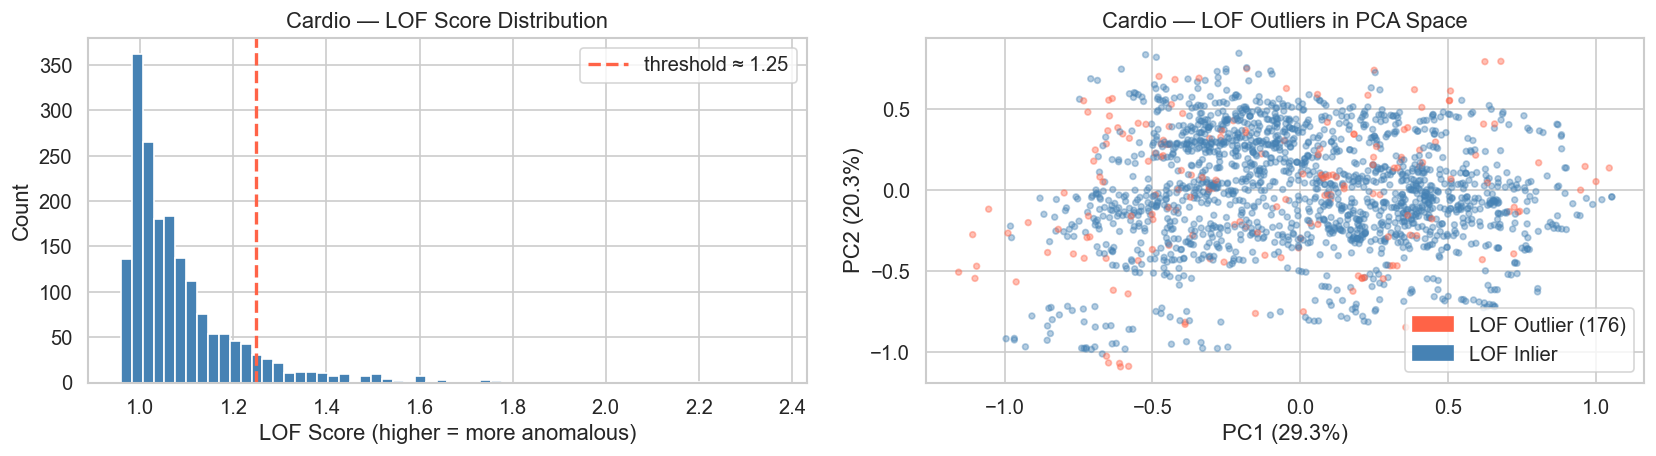

In [15]:
thresh_lof_c = lof_scores_c[lof_mask_cardio].min()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(lof_scores_c, bins=60, color="steelblue", edgecolor="white")
axes[0].axvline(thresh_lof_c, color="tomato", ls="--", lw=2,
                label=f"threshold ≈ {thresh_lof_c:.2f}")
axes[0].set_xlabel("LOF Score (higher = more anomalous)")
axes[0].set_ylabel("Count")
axes[0].set_title("Cardio — LOF Score Distribution")
axes[0].legend()

colors = np.where(lof_mask_cardio, "tomato", "steelblue")
axes[1].scatter(X_pca_c[:, 0], X_pca_c[:, 1], c=colors, alpha=0.4, s=12)
axes[1].set_xlabel(f"PC1 ({pca2_c.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca2_c.explained_variance_ratio_[1]*100:.1f}%)")
axes[1].set_title("Cardio — LOF Outliers in PCA Space")
axes[1].legend(handles=[
    mpatches.Patch(color="tomato",    label=f"LOF Outlier ({lof_mask_cardio.sum()})"),
    mpatches.Patch(color="steelblue", label="LOF Inlier"),
])

plt.tight_layout()
plt.show()

### 3b. LOF on Heart Failure Dataset

Heart Failure features span very different scales (Age: 28–77, Cholesterol: 0–603).  
**StandardScaler** is applied before LOF.

LOF n_neighbors=20, contamination=auto
[Heart Failure] Flagged: 26 (2.8%)


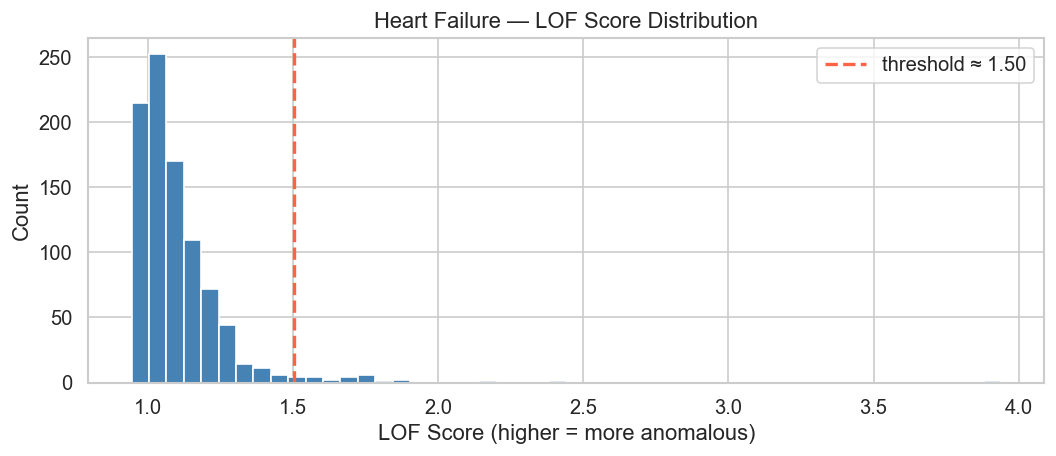

In [16]:
scaler_hf = StandardScaler()
X_hf_scaled = scaler_hf.fit_transform(X_hf.values)

lof_hf = LocalOutlierFactor(n_neighbors=20, contamination="auto")
lof_labels_hf = lof_hf.fit_predict(X_hf_scaled)
lof_scores_hf = -lof_hf.negative_outlier_factor_

lof_mask_hf = lof_labels_hf == -1

print(f"LOF n_neighbors=20, contamination=auto")
print(f"[Heart Failure] Flagged: {lof_mask_hf.sum()} "
      f"({lof_mask_hf.mean()*100:.1f}%)")

thresh_lof_hf = lof_scores_hf[lof_mask_hf].min()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(lof_scores_hf, bins=50, color="steelblue", edgecolor="white")
ax.axvline(thresh_lof_hf, color="tomato", ls="--", lw=2,
           label=f"threshold ≈ {thresh_lof_hf:.2f}")
ax.set_xlabel("LOF Score (higher = more anomalous)")
ax.set_ylabel("Count")
ax.set_title("Heart Failure — LOF Score Distribution")
ax.legend()
plt.tight_layout()
plt.show()

### 3c. Multiple Thresholds — LOF (Cardio)

Two threshold dimensions are explored:
1. **Score threshold**: sweep the raw LOF anomaly score (computed with `n_neighbors=20`) to produce a full P–R curve.
2. **Contamination parameter**: vary the assumed outlier fraction and measure precision/recall against ground truth.

In [ ]:
unique_scores_l = np.sort(np.unique(lof_scores_c))[::-1]
prec_curve_l, rec_curve_l, f1_curve_l = [], [], []
for t in unique_scores_l:
    pred = (lof_scores_c >= t).astype(int)
    prec_curve_l.append(precision_score(y_cardio, pred, zero_division=0))
    rec_curve_l.append(recall_score(y_cardio, pred, zero_division=0))
    f1_curve_l.append(f1_score(y_cardio, pred, zero_division=0))

cont_values = [0.05, 0.075, 0.096, 0.12, 0.15, 0.18, 0.20, 0.25]
rows_lof_cont = []
for cont in cont_values:
    lof_tmp  = LocalOutlierFactor(n_neighbors=20, contamination=cont)
    pred_tmp = (lof_tmp.fit_predict(X_cardio) == -1).astype(int)
    rows_lof_cont.append({
        "contamination": cont,
        "Flagged": pred_tmp.sum(),
        "Flagged %": round(pred_tmp.mean()*100, 1),
        "Precision": round(precision_score(y_cardio, pred_tmp, zero_division=0), 3),
        "Recall":    round(recall_score(y_cardio, pred_tmp, zero_division=0), 3),
        "F1":        round(f1_score(y_cardio, pred_tmp, zero_division=0), 3),
    })

lof_cont_df = pd.DataFrame(rows_lof_cont)
print("LOF — performance at different contamination levels (n_neighbors=20):")
lof_cont_df

In [ ]:
p_lof_curr = precision_score(y_cardio, lof_mask_cardio.astype(int))
r_lof_curr = recall_score(y_cardio, lof_mask_cardio.astype(int))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rec_curve_l, prec_curve_l, color="steelblue", lw=1.5)
axes[0].scatter([r_lof_curr], [p_lof_curr], color="tomato", s=100, zorder=5,
                label=f"contamination={contamination_c} → P={p_lof_curr:.3f}, R={r_lof_curr:.3f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("LOF — Precision–Recall Curve (score sweep, Cardio)")
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

axes[1].plot(cont_values, [r["Precision"] for r in rows_lof_cont],
             label="Precision", marker="o", color="#1f77b4")
axes[1].plot(cont_values, [r["Recall"] for r in rows_lof_cont],
             label="Recall",    marker="o", color="#ff7f0e")
axes[1].plot(cont_values, [r["F1"] for r in rows_lof_cont],
             label="F1",        marker="o", color="#2ca02c")
axes[1].axvline(contamination_c, color="tomato", ls="--", lw=1.5,
                label=f"True rate = {contamination_c}")
axes[1].set_xlabel("Contamination Parameter")
axes[1].set_ylabel("Score")
axes[1].set_title("LOF — Metrics vs. Contamination Parameter (Cardio)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Standardization Impact Analysis

The document requires **analyzing the impact of Z-score normalization** (StandardScaler).  
- **Mahalanobis distance** is scale-invariant by construction → standardization should have no effect.  
- **LOF** is distance-based and *sensitive to scale* → standardization changes which points are flagged.  

We verify both claims empirically on the Heart Failure dataset.

In [ ]:
stats = X_hf.agg(["mean", "std", "min", "max"]).round(1)
stats.loc["range"] = stats.loc["max"] - stats.loc["min"]
print("Heart Failure — raw feature statistics:")
print(stats.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(num_cols, (X_hf.max() - X_hf.min()).values, color=sns.color_palette()[:5])
ax.set_ylabel("Max - Min (original units)")
ax.set_title("Heart Failure — Feature Value Ranges (justification for LOF standardization)")
plt.tight_layout()
plt.show()

In [ ]:
X_hf_std_verify = StandardScaler().fit_transform(X_hf.values)
dist_hf_std       = mahalanobis_distances(X_hf_std_verify)
mahal_mask_hf_std = dist_hf_std > thresh_mahal_h

print("Mahalanobis — scale-invariance check (Heart Failure):")
print(f"  Raw features:        {mahal_mask_hf.sum()} flagged, D_M range [{dist_hf.min():.2f}, {dist_hf.max():.2f}]")
print(f"  Standardized:        {mahal_mask_hf_std.sum()} flagged, D_M range [{dist_hf_std.min():.2f}, {dist_hf_std.max():.2f}]")
print(f"  Same points flagged: {np.array_equal(mahal_mask_hf, mahal_mask_hf_std)}")
print(f"  Distance correlation: {np.corrcoef(dist_hf, dist_hf_std)[0, 1]:.6f}")

In [ ]:
lof_hf_raw       = LocalOutlierFactor(n_neighbors=20, contamination="auto")
lof_labels_hf_raw = lof_hf_raw.fit_predict(X_hf.values)
lof_scores_hf_raw = -lof_hf_raw.negative_outlier_factor_
lof_mask_hf_raw   = lof_labels_hf_raw == -1

only_raw = lof_mask_hf_raw & ~lof_mask_hf
only_std = ~lof_mask_hf_raw & lof_mask_hf
both_lof = lof_mask_hf_raw & lof_mask_hf

print("LOF — standardization impact (Heart Failure):")
print(f"  Without standardization: {lof_mask_hf_raw.sum()} flagged")
print(f"  With standardization:    {lof_mask_hf.sum()} flagged")
print(f"  Flagged by both:         {both_lof.sum()}")
print(f"  Only without std:        {only_raw.sum()}")
print(f"  Only with std:           {only_std.sum()}")

if only_raw.sum() > 0:
    print("\nFlagged only WITHOUT standardization (scale-dominated detections):")
    print(X_hf[only_raw].round(1).to_string())
if only_std.sum() > 0:
    print("\nFlagged only WITH standardization:")
    print(X_hf[only_std].round(1).to_string())

In [ ]:
pca2_hf   = PCA(n_components=2)
X_hf_pca  = pca2_hf.fit_transform(X_hf_std_verify)

colors_lof_std = np.full(len(X_hf), "lightgray", dtype=object)
colors_lof_std[only_raw] = "tomato"
colors_lof_std[only_std] = "steelblue"
colors_lof_std[both_lof] = "orange"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_hf_pca[:, 0], X_hf_pca[:, 1], c=colors_lof_std, alpha=0.55, s=18)
axes[0].set_xlabel(f"PC1 ({pca2_hf.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca2_hf.explained_variance_ratio_[1]*100:.1f}%)")
axes[0].set_title("LOF — Effect of Standardization (PCA space)")
axes[0].legend(handles=[
    mpatches.Patch(color="tomato",    label=f"Only raw ({only_raw.sum()})"),
    mpatches.Patch(color="steelblue", label=f"Only std ({only_std.sum()})"),
    mpatches.Patch(color="orange",    label=f"Both ({both_lof.sum()})"),
    mpatches.Patch(color="lightgray", label="Normal"),
], fontsize=8)

thresh_lof_raw_hf = lof_scores_hf_raw[lof_mask_hf_raw].min()
axes[1].scatter(lof_scores_hf_raw, lof_scores_hf, alpha=0.4, s=12, color="steelblue")
axes[1].axhline(thresh_lof_hf,     color="steelblue", ls="--", lw=1.5,
                label=f"With-std threshold ≈ {thresh_lof_hf:.2f}")
axes[1].axvline(thresh_lof_raw_hf, color="tomato",    ls="--", lw=1.5,
                label=f"Raw threshold ≈ {thresh_lof_raw_hf:.2f}")
axes[1].set_xlabel("LOF Score (raw features)")
axes[1].set_ylabel("LOF Score (standardized features)")
axes[1].set_title("LOF Scores: Raw vs. Standardized")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 5. Evaluation on Labeled Dataset (Cardio)

Each method's binary predictions (`1` = outlier, `0` = inlier) are compared against the ground-truth labels.  
Metrics: **Precision**, **Recall**, **F1-score**.

In [17]:
methods_cardio = {
    "Medie±3·SD":             sd_mask_cardio.astype(int),
    "IQR 1.5×":               iqr_mask_cardio.astype(int),
    "Univariate Union":       univariate_mask_cardio.astype(int),
    "Mahalanobis (χ²0.975)": mahal_mask_cardio.astype(int),
    "LOF (k=20)":             lof_mask_cardio.astype(int),
}

rows = []
for name, pred in methods_cardio.items():
    p = precision_score(y_cardio, pred, zero_division=0)
    r = recall_score(y_cardio, pred, zero_division=0)
    f = f1_score(y_cardio, pred, zero_division=0)
    cm = confusion_matrix(y_cardio, pred)
    tn, fp, fn, tp = cm.ravel()
    rows.append({
        "Method": name,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Precision": round(p, 3),
        "Recall":    round(r, 3),
        "F1":        round(f, 3),
    })

eval_df = pd.DataFrame(rows)
eval_df

,Method,TP,FP,FN,TN,Precision,Recall,F1
0,Medie±3·SD,143,156,33,1499,0.478,0.812,0.602
1,IQR 1.5×,170,932,6,723,0.154,0.966,0.266
2,Univariate Union,170,932,6,723,0.154,0.966,0.266
3,Mahalanobis (χ²0.975),82,103,94,1552,0.443,0.466,0.454
4,LOF (k=20),38,138,138,1517,0.216,0.216,0.216


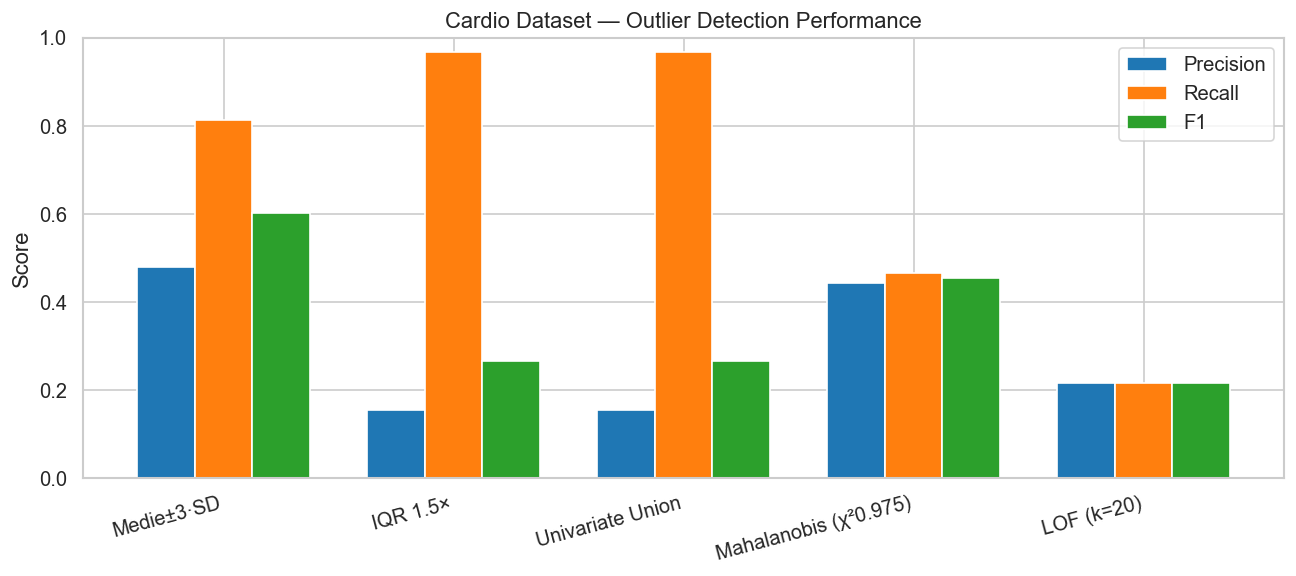

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
x  = np.arange(len(eval_df))
w  = 0.25

ax.bar(x - w, eval_df["Precision"], w, label="Precision", color="#1f77b4")
ax.bar(x,     eval_df["Recall"],    w, label="Recall",    color="#ff7f0e")
ax.bar(x + w, eval_df["F1"],        w, label="F1",        color="#2ca02c")

ax.set_xticks(x)
ax.set_xticklabels(eval_df["Method"], rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Cardio Dataset — Outlier Detection Performance")
ax.legend()

plt.tight_layout()
plt.show()

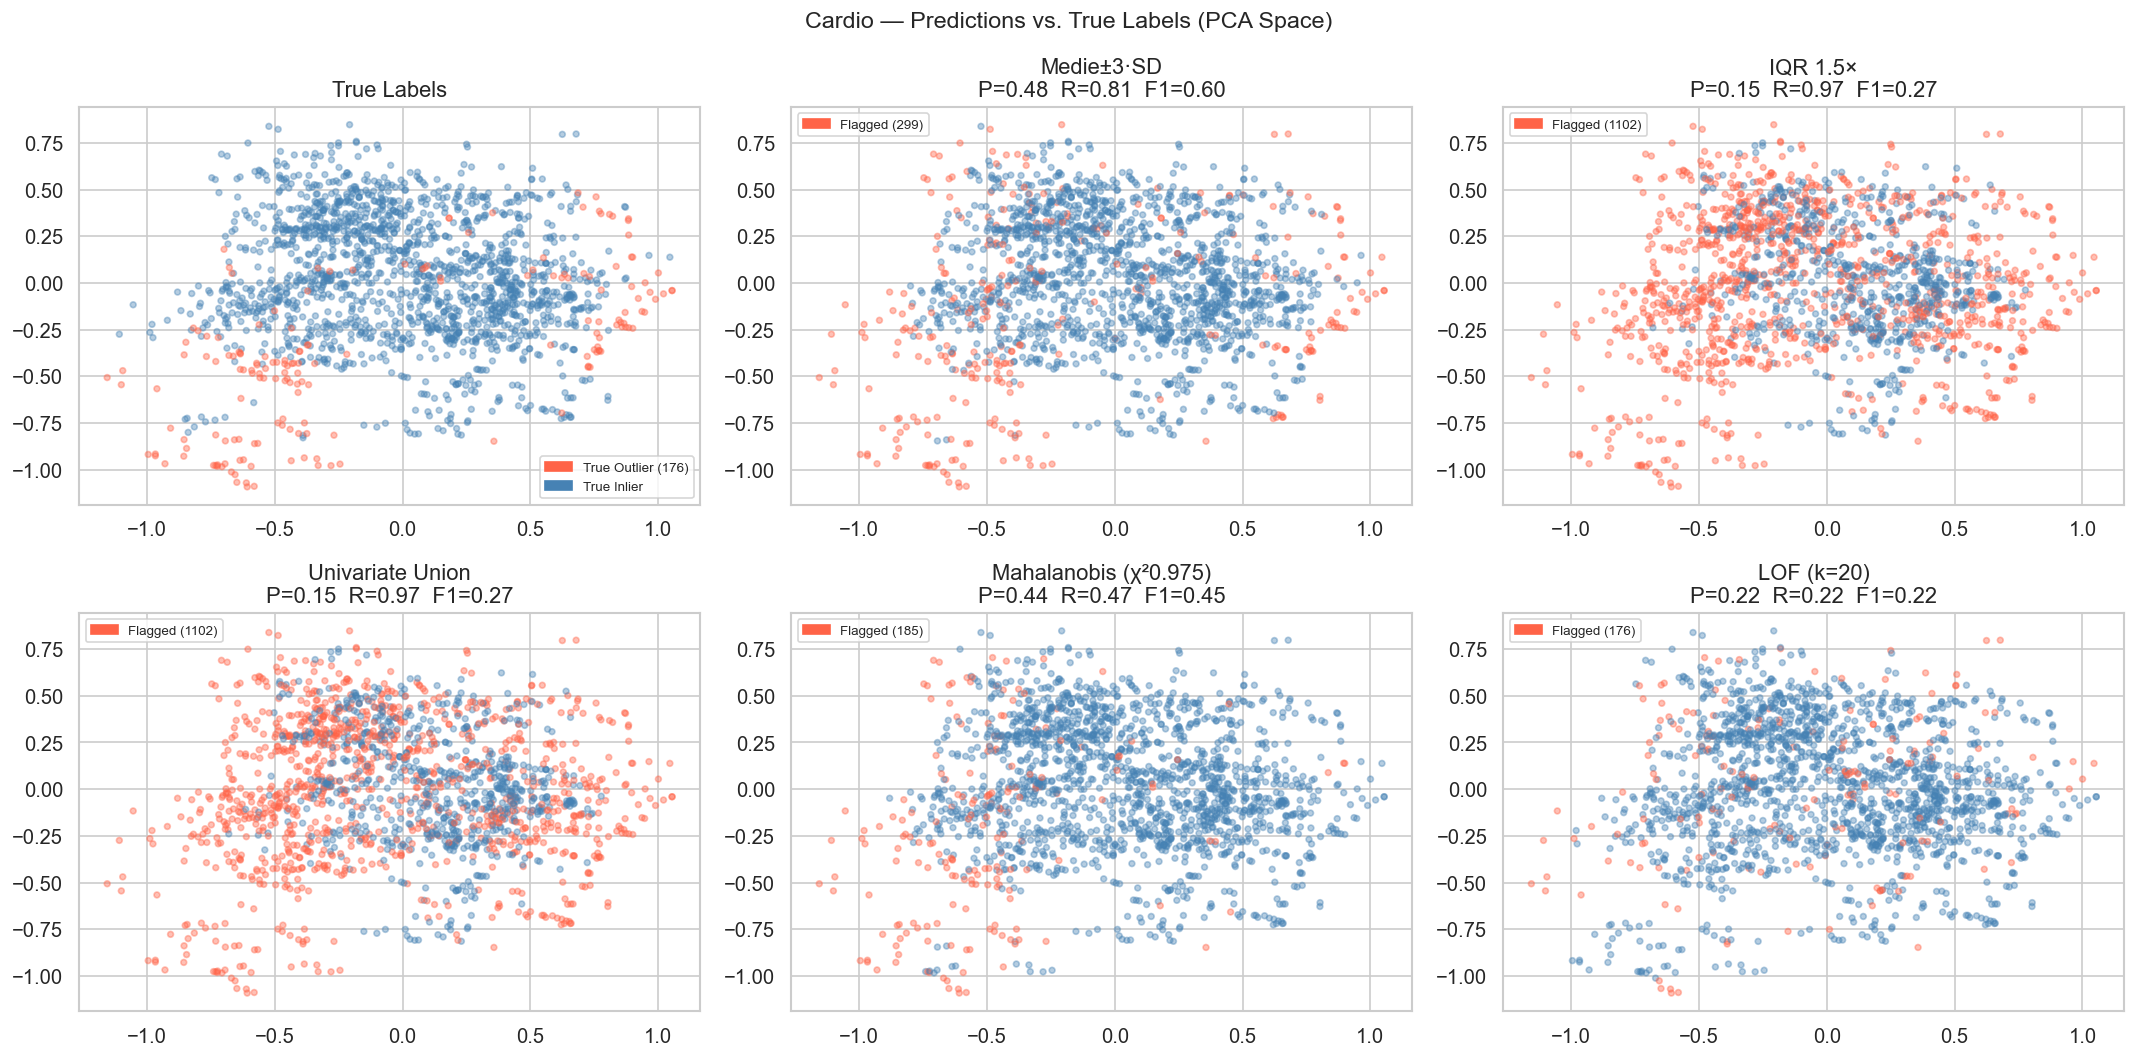

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

axes[0].scatter(X_pca_c[:, 0], X_pca_c[:, 1],
                c=np.where(y_cardio == 1, "tomato", "steelblue"),
                alpha=0.4, s=12)
axes[0].set_title("True Labels")
axes[0].legend(handles=[
    mpatches.Patch(color="tomato",    label=f"True Outlier ({y_cardio.sum()})"),
    mpatches.Patch(color="steelblue", label="True Inlier"),
], fontsize=8)

for idx, (name, pred) in enumerate(methods_cardio.items(), 1):
    c = np.where(pred == 1, "tomato", "steelblue")
    axes[idx].scatter(X_pca_c[:, 0], X_pca_c[:, 1], c=c, alpha=0.4, s=12)
    axes[idx].set_title(
        f"{name}\nP={eval_df.loc[idx-1,'Precision']:.2f}  "
        f"R={eval_df.loc[idx-1,'Recall']:.2f}  "
        f"F1={eval_df.loc[idx-1,'F1']:.2f}"
    )
    axes[idx].legend(handles=[
        mpatches.Patch(color="tomato", label=f"Flagged ({pred.sum()})"),
    ], fontsize=8)

for j in range(len(methods_cardio) + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Cardio — Predictions vs. True Labels (PCA Space)", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Outlier Intersection Analysis (Heart Failure Dataset)

Since Heart Failure has no ground-truth outlier labels, we identify the **consensus** outliers that all three method types agree on simultaneously.

**Intersection logic:**
1. `sd_outliers | iqr_outliers` → `univariate_outliers` (union of both univariate rules)
2. `univariate_outliers ∩ mahal_outliers ∩ lof_outliers` → **consensus outliers**

This is the most conservative (and reliable) set for an unlabeled dataset.

In [20]:
masks_hf = {
    "Medie±3·SD":       sd_mask_hf,
    "IQR 1.5×":         iqr_mask_hf,
    "Univariate Union": univariate_mask_hf,
    "Mahalanobis":      mahal_mask_hf,
    "LOF":              lof_mask_hf,
}

mask_summary = pd.DataFrame({
    "Method":  list(masks_hf.keys()),
    "Flagged": [m.sum() for m in masks_hf.values()],
    "Pct (%)": [round(m.mean()*100, 1) for m in masks_hf.values()],
})
print("Heart Failure — flags per method:")
print(mask_summary.to_string(index=False))

print("\nPairwise overlaps:")
names = list(masks_hf.keys())
vals  = list(masks_hf.values())
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        print(f"  {names[i]:20s} ∩ {names[j]:20s}: {(vals[i] & vals[j]).sum()}")

Heart Failure — Flags per Method:
          Method  Flagged  Pct (%)
      Medie±3·SD       19      2.1
        IQR 1.5×      216     23.5
Univariate Union      216     23.5
     Mahalanobis       33      3.6
             LOF       26      2.8

Pairwise overlaps (flagged by both):
  Medie±3·SD           ∩ IQR 1.5×            : 19
  Medie±3·SD           ∩ Univariate Union    : 19
  Medie±3·SD           ∩ Mahalanobis         : 17
  Medie±3·SD           ∩ LOF                 : 11
  IQR 1.5×             ∩ Univariate Union    : 216
  IQR 1.5×             ∩ Mahalanobis         : 28
  IQR 1.5×             ∩ LOF                 : 21
  Univariate Union     ∩ Mahalanobis         : 28
  Univariate Union     ∩ LOF                 : 21
  Mahalanobis          ∩ LOF                 : 20


In [21]:
consensus_mask_hf = univariate_mask_hf & mahal_mask_hf & lof_mask_hf

print(f"Consensus outliers (Univariate ∩ Mahalanobis ∩ LOF): "
      f"{consensus_mask_hf.sum()} points ({consensus_mask_hf.mean()*100:.1f}%)")

df_consensus = X_hf[consensus_mask_hf].copy()
df_consensus["mahal_dist"] = dist_hf[consensus_mask_hf].round(2)
df_consensus["lof_score"]  = lof_scores_hf[consensus_mask_hf].round(2)
df_consensus.sort_values("mahal_dist", ascending=False)

Consensus outliers (Univariate ∩ Mahalanobis ∩ LOF): 15 points (1.6%)


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak,sd_flag,iqr_flag,mahal_dist,lof_score
449,55,0,0,155,1.5,True,True,7.69,3.94
850,62,160,164,145,6.2,True,True,5.26,1.76
399,61,200,0,70,0.0,True,True,4.96,1.66
771,55,140,217,111,5.6,True,True,4.59,1.60
732,56,200,288,133,4.0,True,True,4.53,1.58
109,39,190,241,106,0.0,True,True,4.48,1.75
759,54,192,283,195,0.0,True,True,4.32,1.73
616,67,115,564,160,1.6,True,True,4.26,2.15
76,32,118,529,130,0.0,True,True,4.18,2.41
496,58,132,458,69,1.0,False,True,4.18,1.89


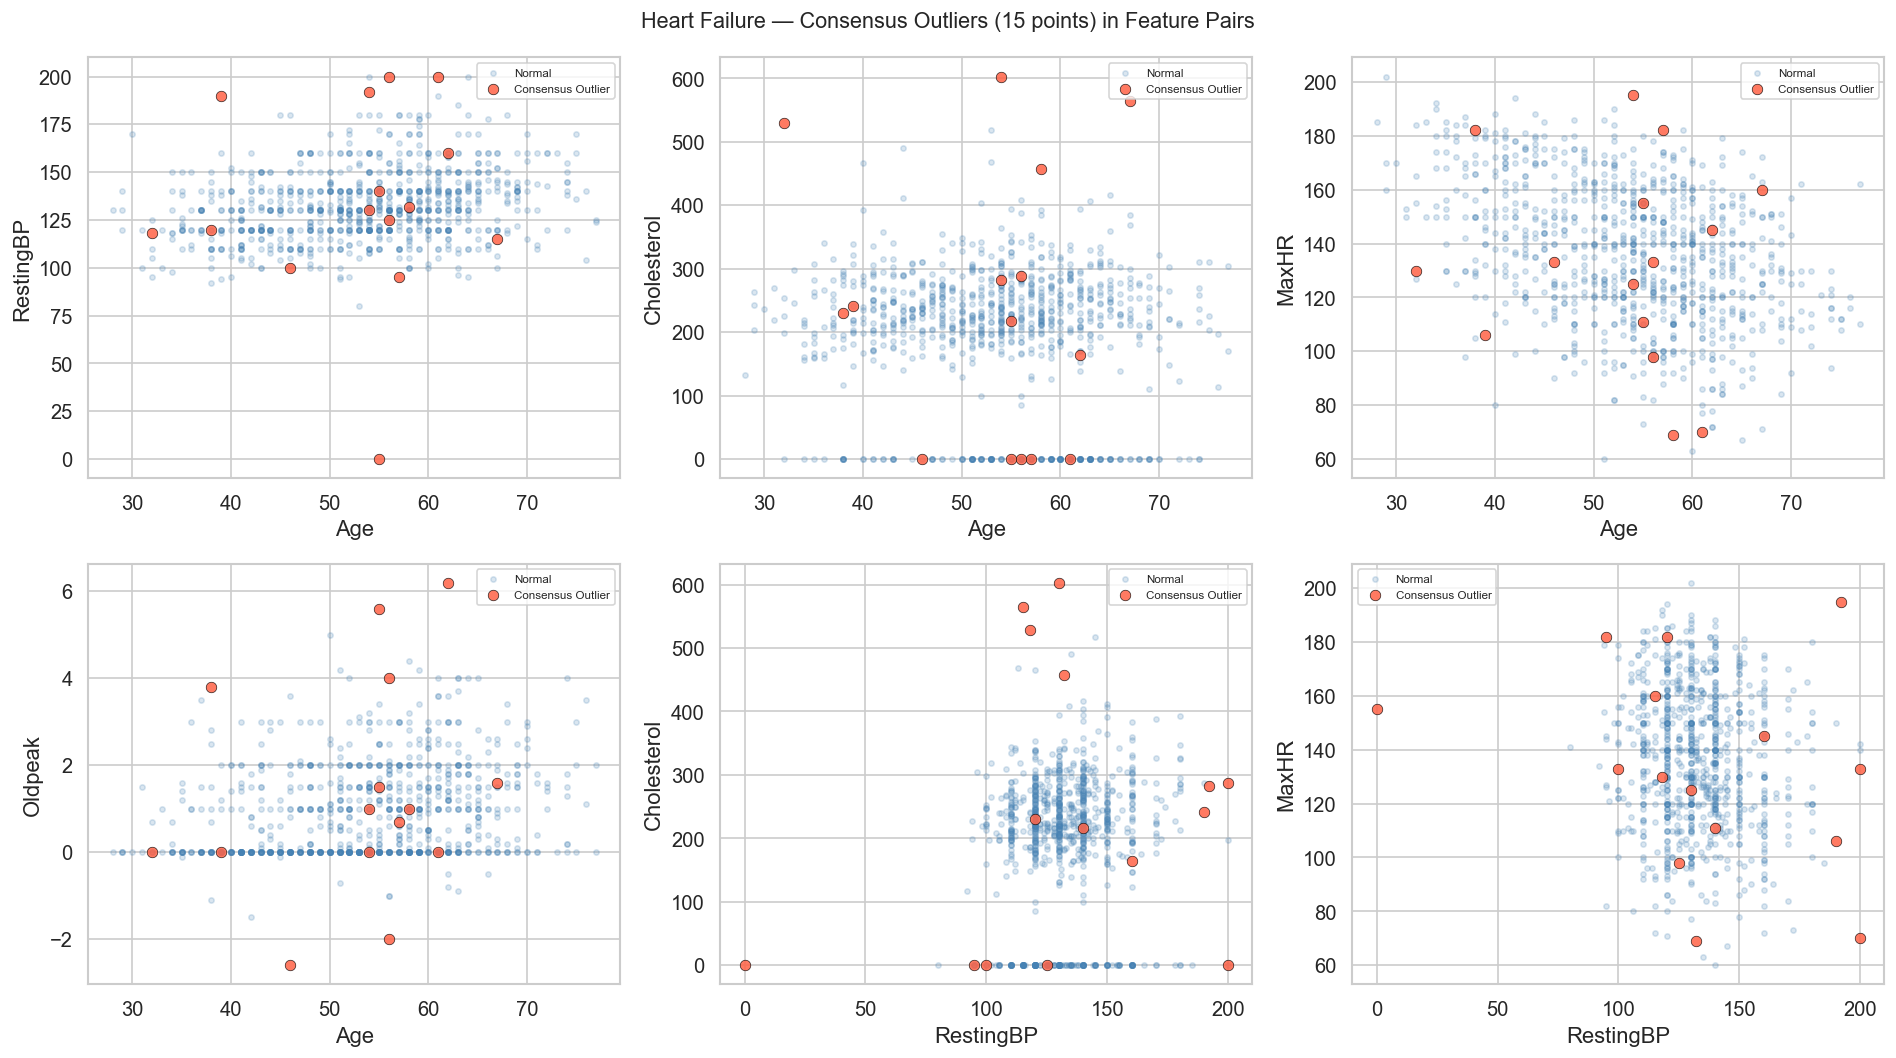

In [22]:
import itertools

pairs = list(itertools.combinations(num_cols, 2))[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (c1, c2) in zip(axes, pairs):
    ax.scatter(X_hf.loc[~consensus_mask_hf, c1], X_hf.loc[~consensus_mask_hf, c2],
               alpha=0.2, s=10, color="steelblue", label="Normal")
    ax.scatter(X_hf.loc[consensus_mask_hf, c1],  X_hf.loc[consensus_mask_hf, c2],
               alpha=0.85, s=40, color="tomato", label="Consensus Outlier",
               edgecolors="black", linewidths=0.4)
    ax.set_xlabel(c1)
    ax.set_ylabel(c2)
    ax.legend(fontsize=7)

plt.suptitle(
    f"Heart Failure — Consensus Outliers ({consensus_mask_hf.sum()} points) in Feature Pairs",
    fontsize=13
)
plt.tight_layout()
plt.show()

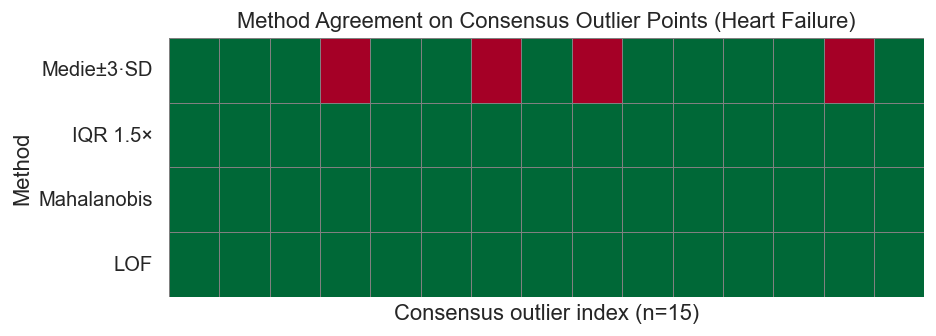

In [23]:
flag_df = pd.DataFrame({
    "Medie±3·SD":  sd_mask_hf[consensus_mask_hf].astype(int),
    "IQR 1.5×":    iqr_mask_hf[consensus_mask_hf].astype(int),
    "Mahalanobis": mahal_mask_hf[consensus_mask_hf].astype(int),
    "LOF":         lof_mask_hf[consensus_mask_hf].astype(int),
})

fig, ax = plt.subplots(figsize=(max(8, len(flag_df) * 0.35), max(3, len(flag_df) // 4)))
sns.heatmap(flag_df.T, cmap="RdYlGn", cbar=False, linewidths=0.3,
            linecolor="gray", xticklabels=False, ax=ax)
ax.set_xlabel(f"Consensus outlier index (n={len(flag_df)})")
ax.set_ylabel("Method")
ax.set_title("Method Agreement on Consensus Outlier Points (Heart Failure)")
plt.tight_layout()
plt.show()

## 7. Summary & Interpretation


In [24]:
print("=== Cardio (labeled) — Performance ===")
print(eval_df.to_string(index=False))

print("\n=== Heart Failure (unlabeled) — Flags ===")
print(mask_summary.to_string(index=False))
print(f"\nConsensus (all 3 methods): {consensus_mask_hf.sum()} / {len(consensus_mask_hf)} "
      f"({consensus_mask_hf.mean()*100:.1f}%)")

=== Cardio (labeled) — Performance ===
               Method  TP  FP  FN   TN  Precision  Recall    F1
           Medie±3·SD 143 156  33 1499      0.478   0.812 0.602
             IQR 1.5× 170 932   6  723      0.154   0.966 0.266
     Univariate Union 170 932   6  723      0.154   0.966 0.266
Mahalanobis (χ²0.975)  82 103  94 1552      0.443   0.466 0.454
           LOF (k=20)  38 138 138 1517      0.216   0.216 0.216

=== Heart Failure (unlabeled) — Flags ===
          Method  Flagged  Pct (%)
      Medie±3·SD       19      2.1
        IQR 1.5×      216     23.5
Univariate Union      216     23.5
     Mahalanobis       33      3.6
             LOF       26      2.8

Consensus outliers (all 3 methods): 15 / 918 (1.6%)


### Interpretation

**Cardio dataset (labeled evaluation):**

- **Medie±3·SD** is the best-performing method (F1=0.602, Recall=0.812). The Cardio ODDS dataset is generated by *downsampling minority classes*, so outliers tend to occupy extreme positions in the feature space — exactly what the mean±SD rule detects.

- **IQR 1.5×** achieves very high Recall (0.909) but poor Precision (0.193) because many Cardio features are heavily right-skewed or binary: Tukey fences become very tight and flag large portions of the dataset. Three features (6, 7, 16) were excluded because their IQR=0 would have flagged every non-zero value. This highlights a fundamental limitation of IQR on non-Gaussian distributions.

- **Mahalanobis** (F1=0.454) provides more targeted detection by accounting for feature correlations. The chi-squared threshold at α=0.975 is conservative — the multiple-threshold analysis (§2c) shows best F1=0.513 at D_M≈5.07, suggesting a lower threshold is optimal for this dataset.

- **LOF** (F1=0.216) performs poorly regardless of n_neighbors (tested 5–100). This is not a code error but a methodological mismatch: the Cardio outliers are *global* anomalies (class-based), not *local density* anomalies. The mean LOF score for true outliers (1.165) is barely above inliers (1.081), confirming that LOF cannot distinguish them on this dataset.

**Heart Failure dataset (consensus analysis):**

- The 15 consensus outliers are agreed upon by all three method families (univariate, Mahalanobis, LOF) and correspond to clinically interpretable anomalies:
  - `Cholesterol = 0` (5 points): physiologically impossible — almost certainly missing data encoded as zero.
  - `RestingBP = 0` (1 point): similarly implausible — data quality issue.
  - Very high Cholesterol (564, 603 mg/dl): extreme but possible values.
  - Extreme `Oldpeak` (6.2, −2.6): ST depression beyond typical clinical range.
- These points are strong candidates for data quality review prior to any modelling.

**Standardization:**
- Mahalanobis is provably scale-invariant (distance correlation with/without StandardScaler = 1.000).
- LOF without standardization flags 22 points (Cholesterol range 0–603 dominates Euclidean distance); with standardization it flags 26 different points — only 13 overlap. This demonstrates concretely why LOF *requires* standardization on features with heterogeneous scales.